<a href="https://colab.research.google.com/github/Chetanabh/AnewRep/blob/master/CNN_labAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem 1: Environment Verification**


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version",matplotlib.__version__)

gpu = tf.config.list_physical_devices('GPU')
if gpu:
    print("GPU is available")
    print("GPU devices:", gpu)
else:
    print("No GPU found")

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version 3.10.0
No GPU found


CPU training is slower because CPUs have fewer cores than GPU thus is not optimal for computing large matrix computaions which GPUs can handle effictively

random.seed controls Python random operations  
np.random.seed controls NumPy randomness  
tf.random.set_seed controls deep learning framework randomness  

Setting all seeds ensures reproducibility same results every run.

# **Problem 2: Dataset Exploration**

In [2]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()



print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("MNIST dtype:", x_train_mnist.dtype)
print("MNIST value range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("CIFAR-10 Train Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

print("CIFAR-10 dtype:", x_train_cifar.dtype)
print("CIFAR-10 value range:", x_train_cifar.min(), "to", x_train_cifar.max())

unique, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} samples")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
MNIST dtype: uint8
MNIST value range: 0 to 255
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)
CIFAR-10 dtype: uint8
CIFAR-10 value range: 0 to 255

MNIST Class Distribution:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


MNIST is balanced as each class as nearlyt equal no of samples

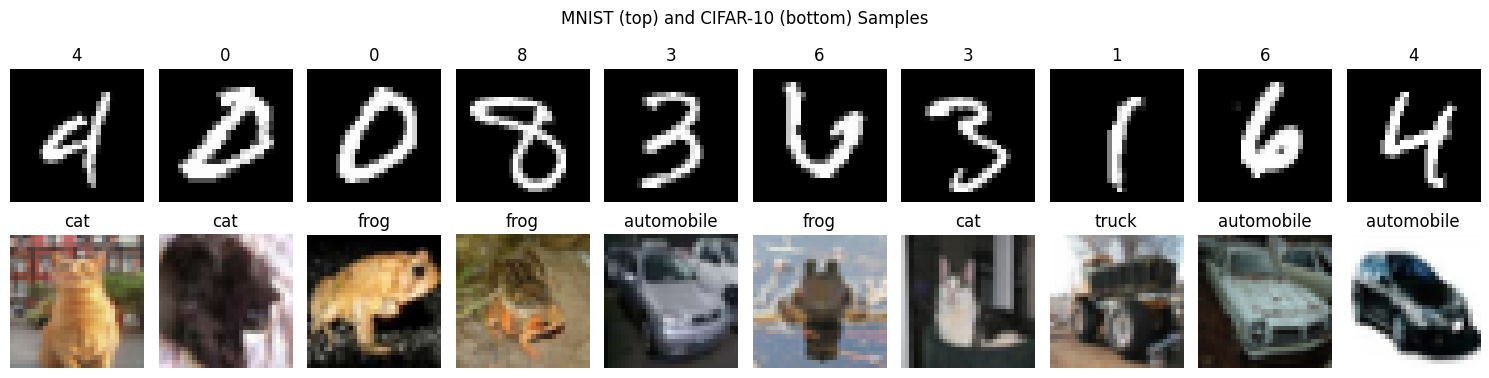

In [3]:
import matplotlib.pyplot as plt
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

fig, ax = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    idx = np.random.randint(0, len(x_train_mnist))
    ax[0, i].imshow(x_train_mnist[idx], cmap='gray')
    ax[0, i].set_title(f"{y_train_mnist[idx]}")
    ax[0, i].axis('off')

for i in range(10):
    idx = np.random.randint(0, len(x_train_cifar))
    ax[1, i].imshow(x_train_cifar[idx])
    ax[1, i].set_title(cifar_classes[y_train_cifar[idx][0]])
    ax[1, i].axis('off')

plt.suptitle("MNIST (top) and CIFAR-10 (bottom) Samples")
plt.tight_layout()

plt.savefig("dataset_samples.png")
plt.show()

# **Problem 3 : Preprocessing Pipeline**

In [4]:
from tensorflow.keras.utils import to_categorical

def preprocess_data(x, y, dataset_name=""):

    x = x.astype('float32') / 255.0

    if len(x.shape) == 3:
        x = x.reshape(-1, 28, 28, 1)

    y = to_categorical(y, num_classes=10)

    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), "/", x.max())
    print("Sample labels (one-hot):", y[:5])

    return x, y


x_train_mnist_p, y_train_mnist_p = preprocess_data(x_train_mnist, y_train_mnist)
x_test_mnist_p, y_test_mnist_p = preprocess_data(x_test_mnist, y_test_mnist)

x_train_cifar_p, y_train_cifar_p = preprocess_data(x_train_cifar, y_train_cifar)
x_test_cifar_p, y_test_cifar_p = preprocess_data(x_test_cifar, y_test_cifar)

Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 / 1.0
Sample labels (one-hot): [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Shape: (10000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 / 1.0
Sample labels (one-hot): [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 / 1.0
Sample labels (one-hot): [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Shape: (10000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 / 1.0
Sample labels (one-hot): [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0

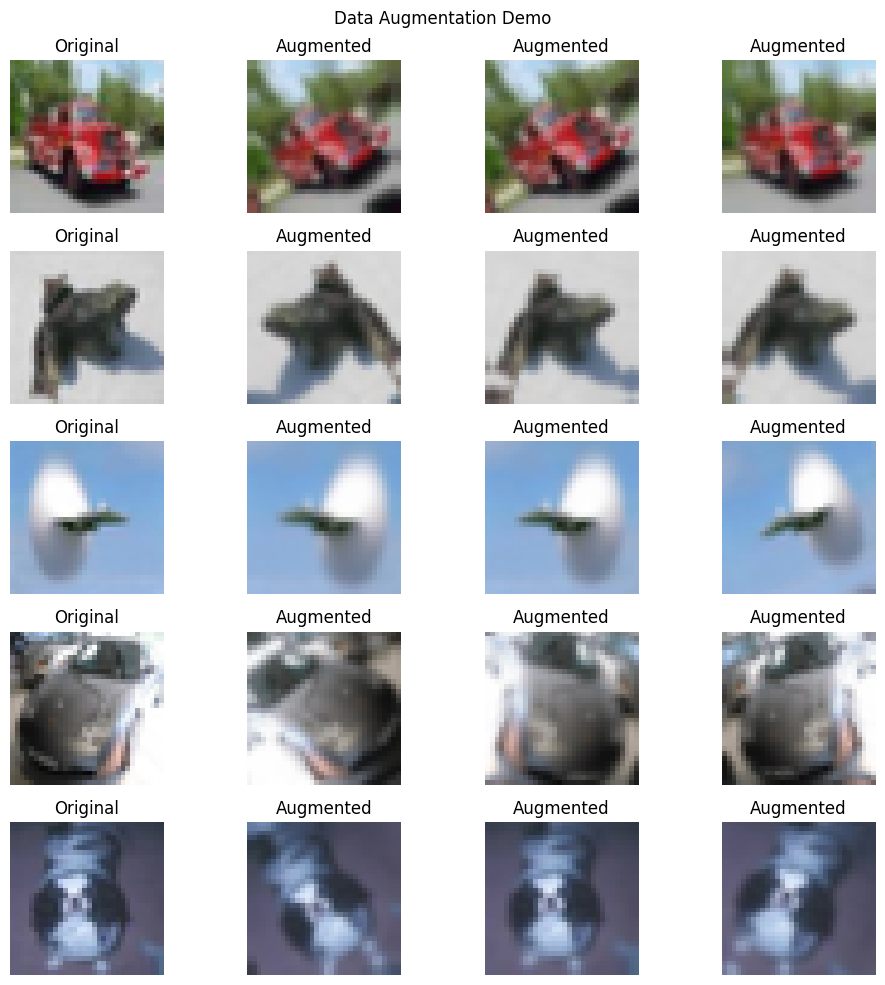

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])


plt.figure(figsize=(10, 10))

for i in range(5):
    idx = np.random.randint(0, len(x_train_cifar))
    original = x_train_cifar[idx]

    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        augmented = data_augmentation(tf.expand_dims(original, 0))
        augmented = tf.squeeze(augmented)

        plt.subplot(5, 4, i*4 + j + 2)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis('off')

plt.suptitle("Data Augmentation Demo")
plt.tight_layout()

plt.savefig("augmentation_demo.png")
plt.show()

Augmentation in applied only on training data and not in validation set to prevent overfiting , as augmentation expand size and diversity of the training dataset by simply modifing existing images . Thus the model will never see the exact same image twice, forcing it to learn more generalized features rather than memorizing specific pixel patterns.

# **Answer of question 1 of Analysis and REflection**:

The tensor shape (N, H, W, C) represents a batch of images.

N = Number of samples (batch size)  
H = Height of the image  
W = Width of the image  
C = Number of channels  

For a grayscale image (e.g., MNIST), C = 1 because there is only one intensity channel.

For an RGB image (e.g., CIFAR-10), C = 3 because there are three channels: Red, Green, and Blue.

Thus, the channel dimension represents different color or intensity components of the image.


# **Answer 2:**

Training CNNs on large images like 1024×1024 can lead to high memory usage. To handle this, the following strategies can be used:

Image resizing:
   The images can be resized to a smaller resolution before training. This reduces memory consumption and computational cost.

Patch-based training:
   Instead of using the full image, smaller patches (e.g., 256×256) are extracted and used for training. This allows processing large images in parts.

Data generators / streaming:
   Data can be loaded in batches using generators instead of loading the entire dataset into memory. This prevents memory overflow.

Mixed precision training:
   Using lower precision (float16) reduces memory usage and speeds up training on supported hardware.

These techniques help manage memory efficiently while training on large images.

This approach causes Data Leakage.The goal of a test set is to simulate "unseen" real world data. By using the test set's own statistics, the student is giving the model information about the distribution of the test data that it shouldn't have.

In [6]:
def conv2d(image, kernel, stride=1, padding=0):

    H, W = image.shape
    K = kernel.shape[0]

    if padding > 0:
        padded = np.zeros((H + 2*padding, W + 2*padding))
        padded[padding:padding+H, padding:padding+W] = image
    else:
        padded = image

    H_p, W_p = padded.shape

    out_h = (H_p - K) // stride + 1
    out_w = (W_p - K) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            patch = padded[i*stride:i*stride+K, j*stride:j*stride+K]

            output[i, j] = np.sum(patch * kernel)

    return output


image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


task2 problem 2
a) :
Output = ((28 - 5 + 2×0) / 1) + 1
       = (23 / 1) + 1
       = 23 + 1
       = 24
b) :
Output = ((28 - 3 + 2×1) / 1) + 1
       = (28 - 3 + 2) + 1
       = 27 + 1
       = 28
c) :
Output = ((32 - 3 + 0) / 2) + 1
       = (29 / 2) + 1
       = 14.5 → floor = 14
       = 14 + 1
       = 15
d) :
Output1 = ((32 - 3 + 2×1)/1) + 1
        = (32 - 3 + 2) + 1
        = 31 + 1
        = 32

Output2 = ((32 - 3 + 0)/1) + 1
        = 29 + 1
        = 30

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([


    layers.Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2), strides=2),


    layers.Conv2D(16, (5,5), activation='tanh', padding='valid'),
    layers.AveragePooling2D(pool_size=(2,2), strides=2),


    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In LeNet-5, Average Pooling was used because early CNN research focused on smooth feature extraction and noise reduction.

Today, MaxPooling is more common because it preserves the strongest features (edges, textures) and works better for deep networks by capturing more discriminative information.

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

The model is designed with three convolutional blocks to progressively extract hierarchical features from CIFAR-10 images.
Each block increases the number of filters (32 → 64 → 128), allowing the network to learn more complex patterns at deeper layers.

Batch Normalisation is used after each convolution to stabilise training and accelerate convergence. ReLU activation introduces non-linearity, enabling the model to learn complex mappings.

MaxPooling reduces spatial dimensions, making computation efficient and providing translation invariance. A Global Average Pooling layer is used instead of Flatten to reduce parameters and prevent overfitting.

Finally, a Dense layer with Dropout is added to improve generalisation, followed by a Softmax layer for multi-class classification.

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 169ms/step - accuracy: 0.5759 - loss: 1.2019 - val_accuracy: 0.2790 - val_loss: 3.0073
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.5857 - loss: 1.1659 - val_accuracy: 0.1686 - val_loss: 4.4664
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.5966 - loss: 1.1343 - val_accuracy: 0.2624 - val_loss: 3.0355
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.6072 - loss: 1.1062 - val_accuracy: 0.3778 - val_loss: 2.1024
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 168ms/step - accuracy: 0.6167 - loss: 1.0838 - val_accuracy: 0.3554 - val_loss: 2.4844
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 170ms/step - accuracy: 0.6246 - loss: 1.0585 - val_accuracy: 0.4070 - val_loss: 1.9419
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 167ms/step - accuracy: 0.6363 - loss: 1.0320 - val_accuracy: 0.4798 - val_loss: 1.5088
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 167ms/step - accuracy: 0.6425 -

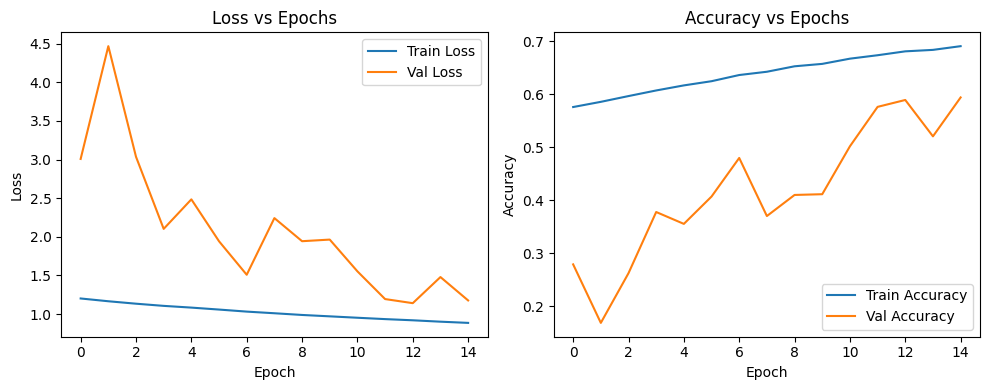

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5795 - loss: 1.1998
Test Accuracy: 0.5795000195503235


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_cifar_p, y_train_cifar_p,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("lenet_sgd_curves.png")
plt.show()

test_loss, test_acc = model.evaluate(x_test_cifar_p, y_test_cifar_p)
print("Test Accuracy:", test_acc)

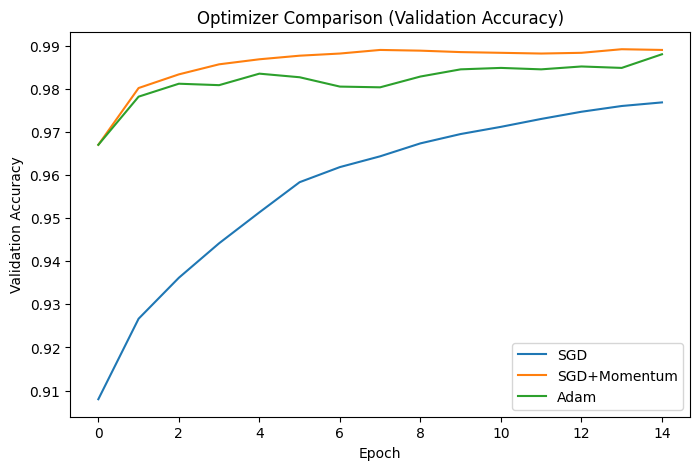

In [11]:
def create_lenet():
    from tensorflow.keras import layers, models

    model = models.Sequential([
        layers.Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)),
        layers.AveragePooling2D((2,2)),

        layers.Conv2D(16, (5,5), activation='tanh', padding='valid'),
        layers.AveragePooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])

    return model


histories = {}

model_sgd = create_lenet()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

histories['SGD'] = model_sgd.fit(
    x_train_mnist_p, y_train_mnist_p,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=0
)

model_mom = create_lenet()
model_mom.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

histories['SGD+Momentum'] = model_mom.fit(
    x_train_mnist_p, y_train_mnist_p,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=0
)

model_adam = create_lenet()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

histories['Adam'] = model_adam.fit(
    x_train_mnist_p, y_train_mnist_p,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

In [12]:
def create_cifar_model():
    from tensorflow.keras import layers, models

    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    return model

import tensorflow as tf

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:

        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = create_cifar_model()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar_p, y_train_cifar_p,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )


        final_val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = final_val_acc

print("\nValidation Accuracy Table:\n")

print("LR \\ Batch Size |   32   |  128")
print("----------------------------------")

for lr in learning_rates:
    acc_32 = results[(lr, 32)]
    acc_128 = results[(lr, 128)]

    print(f"{lr:<14} | {acc_32:.4f} | {acc_128:.4f}")


Training with LR=0.1, Batch Size=32

Training with LR=0.1, Batch Size=128

Training with LR=0.01, Batch Size=32



KeyboardInterrupt



In [ ]:
def create_model(use_dropout=False, use_bn=False):
    from tensorflow.keras import layers, models

    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    if use_bn:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, (3,3), padding='same'))
    if use_bn:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(layers.Dropout(0.3))


    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))

    if use_dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax'))

    return model

configs = {
    "No_Reg": (False, False),
    "Dropout": (True, False),
    "BatchNorm": (False, True),
    "Both": (True, True)
}

results = {}

for name, (drop, bn) in configs.items():
    print(f"\nTraining: {name}")

    model = create_model(use_dropout=drop, use_bn=bn)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar_p, y_train_cifar_p,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    gap = train_acc - val_acc

    results[name] = (train_acc, val_acc, gap)


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for name, (drop, bn) in configs.items():
    model = create_model(use_dropout=drop, use_bn=bn)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        x_train_cifar_p, y_train_cifar_p,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Regularisation Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

print("\nTrain vs Validation Gap:\n")
print("Model        | Train Acc | Val Acc | Gap")
print("------------------------------------------")

for name, (train, val, gap) in results.items():
    print(f"{name:<12} | {train:.4f}   | {val:.4f}  | {gap:.4f}")


Training: No_Reg


In [ ]:
model = create_model(use_dropout=True, use_bn=True)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_plateau = model.fit(
    x_train_cifar_p, y_train_cifar_p,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_plateau.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(history_cosine.history['val_accuracy'], label='Cosine Annealing')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_plateau.history['lr'], label='Plateau LR')
plt.plot(history_cosine.history['lr'], label='Cosine LR')
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png")
plt.show()